Original image dimensions: 334 x 650

Source points:
[[100. 100.]
 [500. 120.]
 [550. 500.]
 [ 80. 480.]]

Destination points:
[[  0.   0.]
 [599.   0.]
 [599. 599.]
 [  0. 599.]]

Perspective transformation matrix:
[[ 1.54664822e+00  8.14025380e-02 -1.62805076e+02]
 [-9.64970483e-02  1.92994097e+00 -1.83344392e+02]
 [-4.44822545e-05  4.81493801e-04  1.00000000e+00]]

Output size: 600 x 600
Saved: task8_birds_eye.jpg


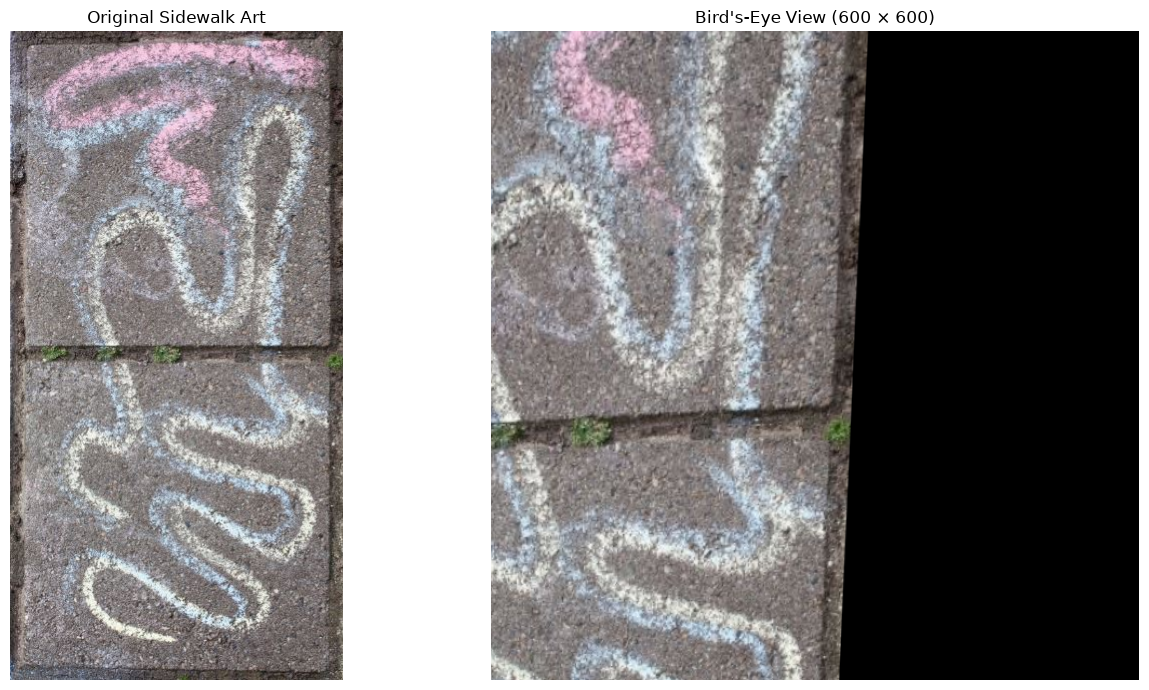

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Input and output files
# ---------------------------------------------------------
image_path = "sidewalk_art.jpg"
output_path = "task8_birds_eye.jpg"

# ---------------------------------------------------------
# Output square size
# ---------------------------------------------------------
n = 600

# ---------------------------------------------------------
# SOURCE POINTS
#
# Enter the four corners of the sidewalk artwork.
#
# Order MUST be:
# 1. Top-Left
# 2. Top-Right
# 3. Bottom-Right
# 4. Bottom-Left
#
# Replace these example coordinates with the actual
# coordinates from your image.
# ---------------------------------------------------------
src = np.array([
    [100, 100],   # Top-Left
    [500, 120],   # Top-Right
    [550, 500],   # Bottom-Right
    [80, 480]     # Bottom-Left
], dtype=np.float32)

# ---------------------------------------------------------
# Read image
# ---------------------------------------------------------
img = cv2.imread(image_path)

if img is None:
    raise FileNotFoundError(f"Could not find image: {image_path}")

print("Original image dimensions:", img.shape[1], "x", img.shape[0])

# ---------------------------------------------------------
# DESTINATION POINTS
#
# Map the four corners to a 600 x 600 square.
# ---------------------------------------------------------
dst = np.array([
    [0, 0],           # Top-Left
    [n - 1, 0],       # Top-Right
    [n - 1, n - 1],   # Bottom-Right
    [0, n - 1]        # Bottom-Left
], dtype=np.float32)

print("\nSource points:")
print(src)

print("\nDestination points:")
print(dst)

# ---------------------------------------------------------
# Calculate perspective transformation matrix
# ---------------------------------------------------------
H = cv2.getPerspectiveTransform(src, dst)

print("\nPerspective transformation matrix:")
print(H)

# ---------------------------------------------------------
# Apply perspective transformation
# ---------------------------------------------------------
result = cv2.warpPerspective(
    img,
    H,
    (n, n)
)

# ---------------------------------------------------------
# Save bird's-eye view
# ---------------------------------------------------------
cv2.imwrite(output_path, result)

print("\nOutput size:", n, "x", n)
print("Saved:", output_path)

# ---------------------------------------------------------
# Convert BGR to RGB for Matplotlib
# ---------------------------------------------------------
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
result_rgb = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)

# ---------------------------------------------------------
# Display original and transformed images in Jupyter
# ---------------------------------------------------------
plt.figure(figsize=(14, 7))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title("Original Sidewalk Art")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(result_rgb)
plt.title("Bird's-Eye View (600 × 600)")
plt.axis("off")

plt.tight_layout()
plt.show()
